In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [2]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.2’

survey-results-publ 100%[===================>] 201.62M  7.44MB/s    in 33s     
2026-08-14 10:28:11 (6.02 MB/s) - ‘survey-results-public.sqlite.2’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [3]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 122.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')

q="SELECT * FROM main" 
df=pd.read_sql_query(q,conn)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df1 = pd.read_sql_query(QUERY, conn)
print(df1)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


<Axes: >

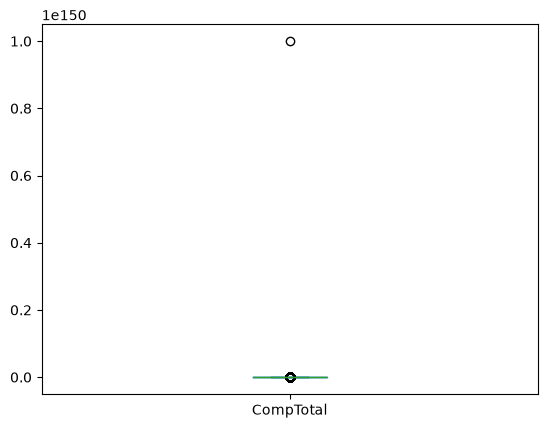

In [9]:
# your code goes here
df["CompTotal"].plot.box()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [10]:
# your code goes here
age_mapping = {
    "Under 18 years old": 15,     # Assuming a realistic range of 13-17 for survey takers
    "18-24 years old": 21,        # Exact median of 18 and 24
    "25-34 years old": 29,        # Exact median of 25 and 34
    "35-44 years old": 39,        # Exact median of 35 and 44
    "45-54 years old": 49,        # Exact median of 45 and 54
    "55-64 years old": 59,        # Exact median of 55 and 64
    "65 years or older": 70# Assuming an active developer range up to 75
}

# Create a new numeric Age column
df['Age_numeric'] = df['Age'].map(age_mapping)

<Axes: >

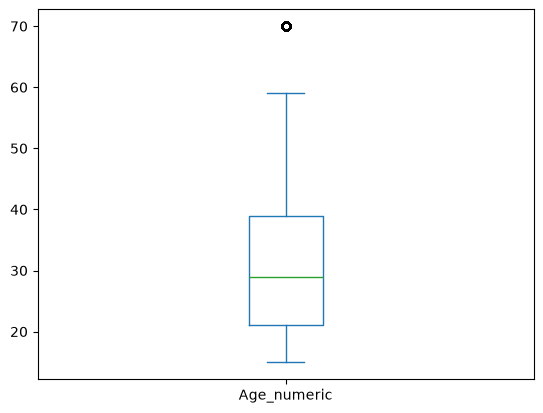

In [11]:
df["Age_numeric"].plot.box()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [12]:
# your code goes here
!pip install seaborn
import seaborn as sns

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '25-34 years old'),
  Text(1, 0, '35-44 years old'),
  Text(2, 0, '45-54 years old'),
  Text(3, 0, '55-64 years old'),
  Text(4, 0, '18-24 years old'),
  Text(5, 0, '65 years or older'),
  Text(6, 0, 'Under 18 years old'),
  Text(7, 0, 'Prefer not to say')])

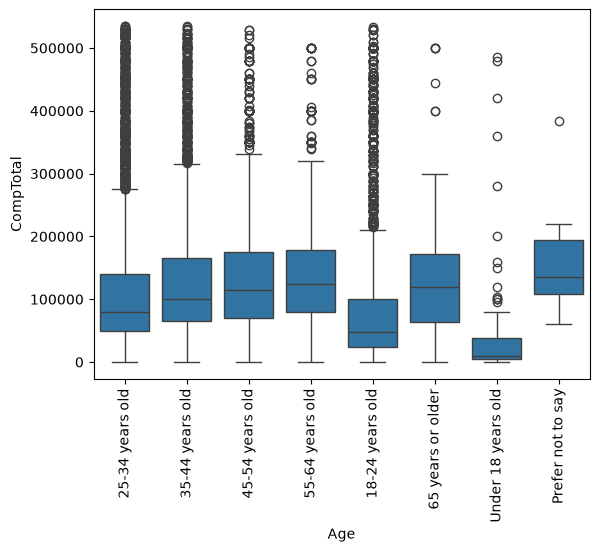

In [13]:
# 1. Calculate Q1, Q3, and IQR
Q1 = df["CompTotal"].quantile(0.25)
Q3 = df["CompTotal"].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 3. Filter the dataframe to remove outliers
df = df[
    (df["CompTotal"] >= lower) & 
    (df["CompTotal"] <= upper)
]


sns.boxplot(data=df,x="Age",y="CompTotal")
plt.xticks(rotation=90)

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85],
 [Text(0, 0, '0.0'),
  Text(1, 0, '1.0'),
  Text(2, 0, '2.0'),
  Text(3, 0, '3.0'),
  Text(4, 0, '4.0'),
  Text(5, 0, '5.0'),
  Text(6, 0, '6.0'),
  Text(7, 0, '7.0'),
  Text(8, 0, '8.0'),
  Text(9, 0, '9.0'),
  Text(10, 0, '10.0'),
  Text(11, 0, '11.0'),
  Text(12, 0, '12.0'),
  Text(13, 0, '12.5'),
  Text(14, 0, '13.0'),
  Text(15, 0, '14.0'),
  Text(16, 0, '15.0'),
  Text(17, 0, '16.0'),
  Text(18, 0, '17.0'),
  Text(19, 0, '17.5'),
  Text(20, 0, '18.0'),
  Text(21, 0, '19.0'),
  Text(

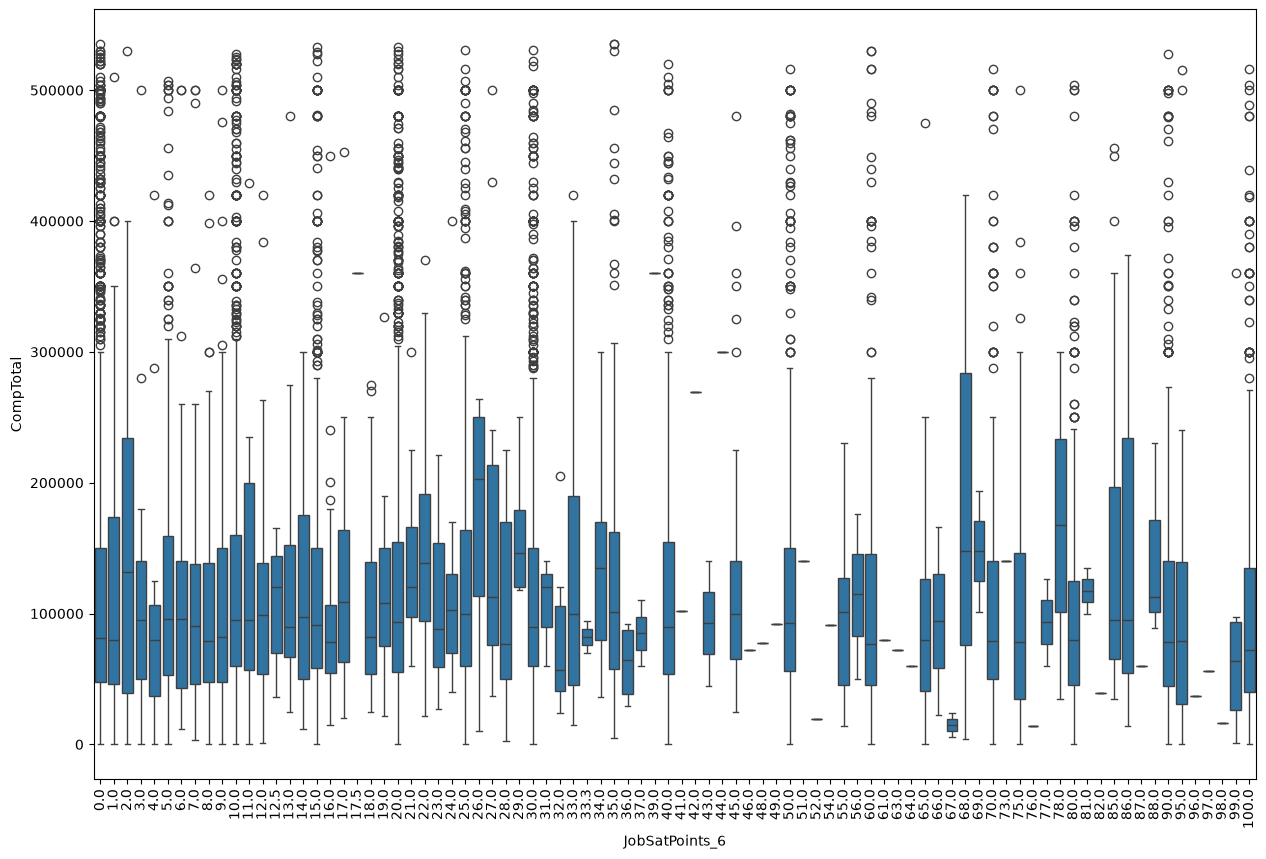

In [14]:
# your code goes here
fig=plt.figure(figsize=(15,10))
sns.boxplot(data=df,x="JobSatPoints_6",y="CompTotal")
plt.xticks(rotation=90)

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Developer, back-end'),
  Text(1, 0, 'Developer, full-stack'),
  Text(2, 0, 'Developer, front-end'),
  Text(3, 0, 'Developer, mobile'),
  Text(4, 0, 'Developer, desktop or enterprise applications')])

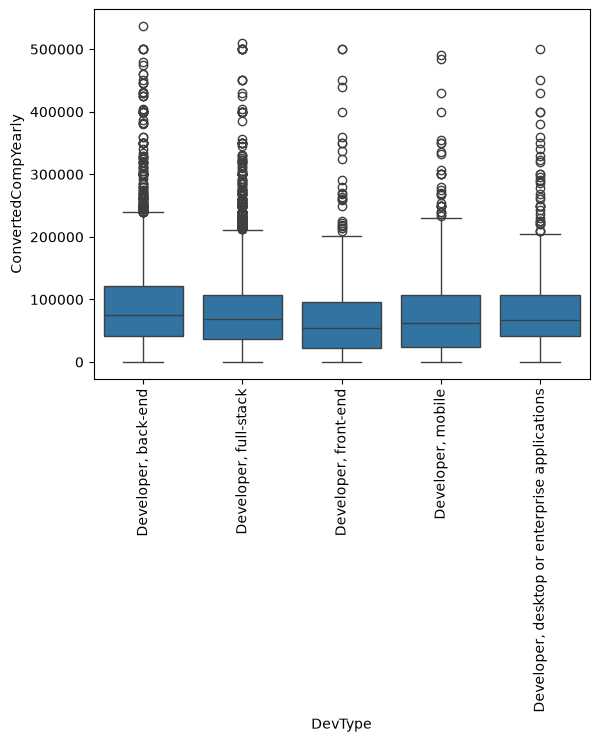

In [26]:
# your code goes here
data=df["DevType"].value_counts().head().index
dt=df[df["DevType"].isin(data)]
sns.boxplot(data=dt,x="DevType",y="ConvertedCompYearly")
plt.xticks(rotation=90)

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


([0, 1, 2, 3, 4],
 [Text(0, 0, 'France'),
  Text(1, 0, 'United States of America'),
  Text(2, 0, 'United Kingdom of Great Britain and Northern Ireland'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'Canada')])

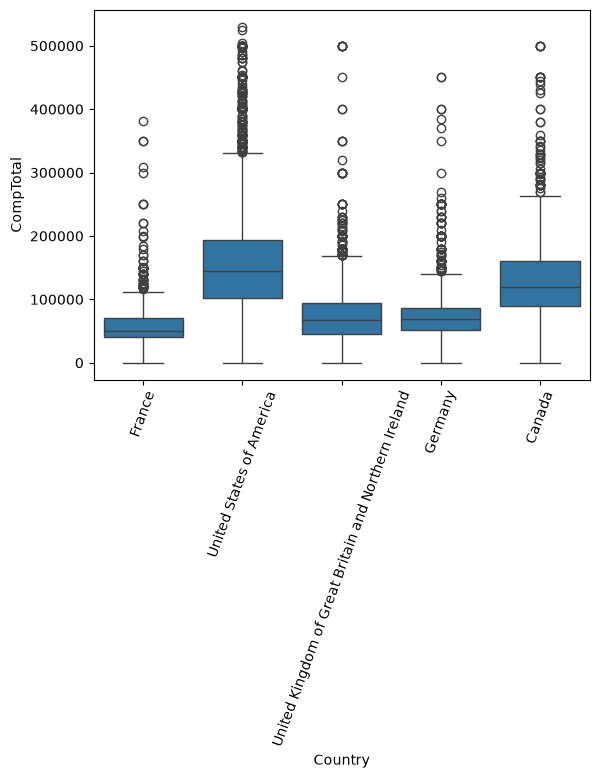

In [29]:
# your code goes here
data=df["Country"].value_counts().head().index 
dt=df[df["Country"].isin(data)] 
sns.boxplot(data=dt,x="Country",y="CompTotal")
plt.xticks(rotation=70)

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Employed, full-time'),
  Text(1, 0, 'Independent contractor, freelancer, or self-employed'),
  Text(2, 0, 'Student, part-time'),
  Text(3, 0, 'Student, full-time'),
  Text(4, 0, 'Employed, part-time'),
  Text(5, 0, 'Retired'),
  Text(6, 0, 'Not employed, but looking for work'),
  Text(7, 0, 'Not employed, and not looking for work')])

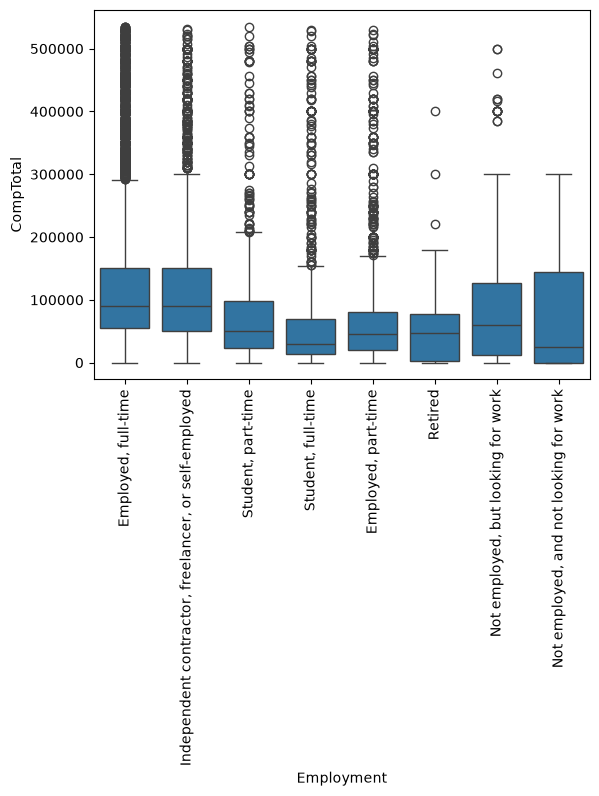

In [31]:
# your code goes here
temp = df[["Employment","CompTotal"]].copy()

temp["Employment"] = temp["Employment"].str.split(";")
temp = temp.explode("Employment", ignore_index=True)
sns.boxplot(data=temp,x="Employment",y="CompTotal")
plt.xticks(rotation=90)

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51],
 [Text(0, 0, '6'),
  Text(1, 0, '17'),
  Text(2, 0, '7'),
  Text(3, 0, '18'),
  Text(4, 0, '25'),
  Text(5, 0, '30'),
  Text(6, 0, '20'),
  Text(7, 0, '50'),
  Text(8, 0, '27'),
  Text(9, 0, '16'),
  Text(10, 0, '1'),
  Text(11, 0, '4'),
  Text(12, 0, '15'),
  Text(13, 0, '11'),
  Text(14, 0, '23'),
  Text(15, 0, '10'),
  Text(16, 0, '8'),
  Text(17, 0, '24'),
  Text(18, 0, '12'),
  Text(19, 0, '26'),
  Text(20, 0, '40'),
  Text(21, 0, 'Less than 1 year'),
  Text(22, 0, '9'),
  Text(23, 0, '22'),
  Text(24, 0, '5'),
  Text(25, 0, '28'),
  Text(26, 0, '3'),
  Text(27, 0, '44'),
  Text(28, 0, '42'),
  Text(29, 0, '13'),
  Text(30, 0, '19'),
  Text(31, 0, '2'),
  Text(32, 0, '35'),
  Text(33

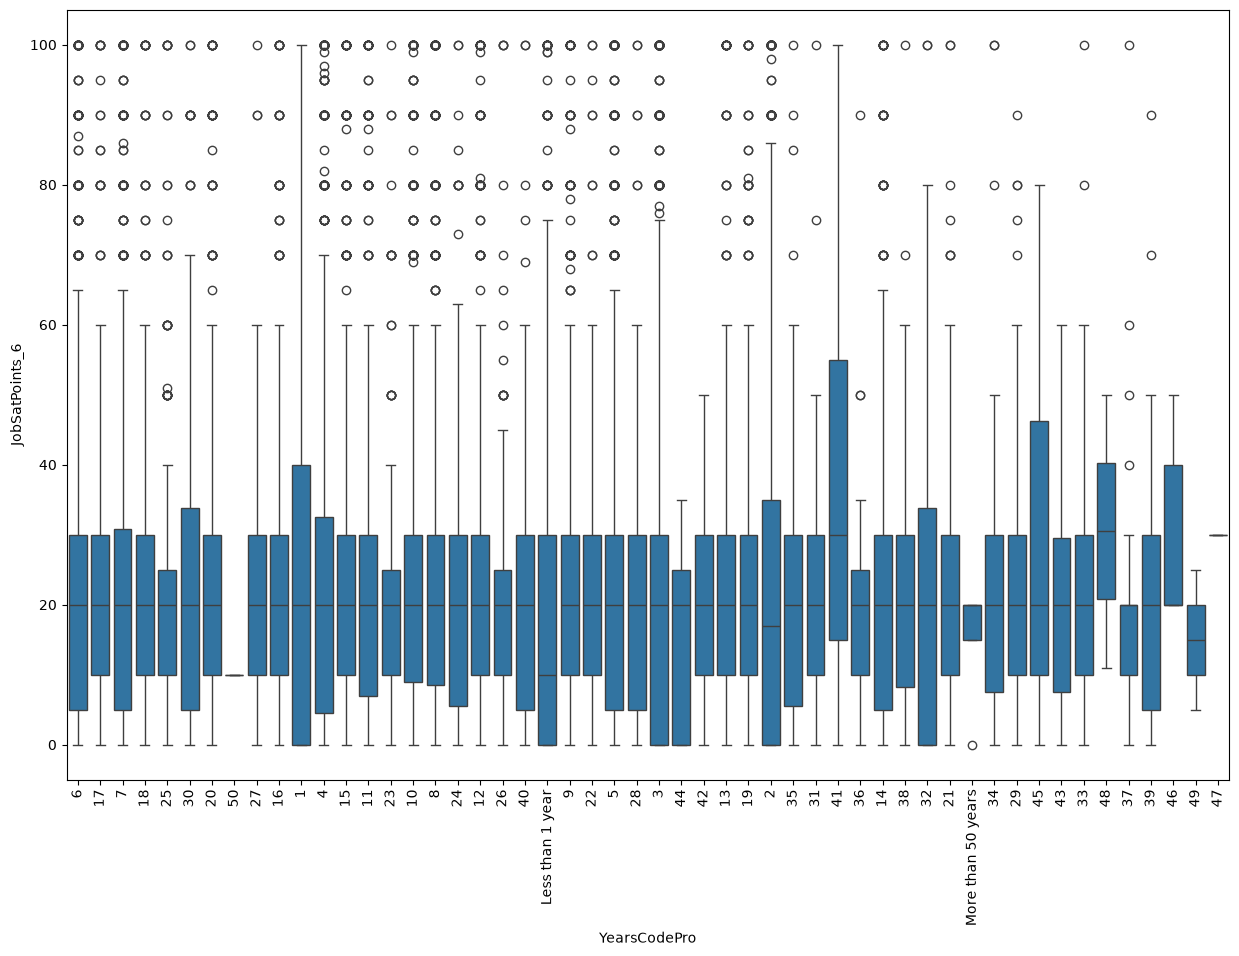

In [33]:
# your code goes here
fig=plt.figure(figsize=(15,10))
sns.boxplot(data=df,x="YearsCodePro",y="JobSatPoints_6") 
plt.xticks(rotation=90)

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [18]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
